# 02 EDA

This notebook performs the required exploratory data analysis for:
- `EverCigaretteUse` (behavior variable)
- `HowMuchDoYouWeighWithoutShoesInKG` (continuous variable)

It also includes an additional subgroup exploration using `WhatIsYourSex` codes.


In [106]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams['figure.dpi'] = 120

ROOT = Path.cwd().resolve().parent
PROCESSED_PATH = ROOT / "data" / "processed" / "yrbs_selected_cleaned.csv"
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"

BEHAVIOR_VAR = "EverCigaretteUse"
CONT_VAR = "HowMuchDoYouWeighWithoutShoesInKG"

processed = pd.read_csv(PROCESSED_PATH)
print("Processed data shape:", processed.shape)
processed.head()

Processed data shape: (14041, 4)


,WhatIsYourSex,EverCigaretteUse,behavior_binary,HowMuchDoYouWeighWithoutShoesInKG
0,2.0,1.0,1.0,NaN
1,2.0,1.0,1.0,68.04
2,2.0,NaN,NaN,NaN
3,1.0,1.0,1.0,79.38
4,1.0,NaN,NaN,NaN


In [107]:

behavior = processed[[BEHAVIOR_VAR, "behavior_binary", "WhatIsYourSex"]].copy()
behavior_valid = behavior.dropna(subset=["behavior_binary"]).copy()
cont = processed[[CONT_VAR, "WhatIsYourSex"]].copy()
cont_valid = cont.dropna(subset=[CONT_VAR]).copy()


## Behavior Variable EDA

In [108]:

behavior_raw_freq = (
    behavior[BEHAVIOR_VAR].value_counts(dropna=False)
    .sort_index()
    .rename_axis("raw_code")
    .reset_index(name="count")
)
display(behavior_raw_freq)


,raw_code,count
0,1.0,7164
1,2.0,6437
2,NaN,440


In [109]:

display(Markdown(
    f"**Observation:** The original behavior variable is already concentrated in codes 1 and 2, "
    f"with {int(behavior[BEHAVIOR_VAR].isna().sum())} missing values. "
    f"This means the variable is straightforward to recode for the proportion analysis."
))


**Observation:** The original behavior variable is already concentrated in codes 1 and 2, with 440 missing values. This means the variable is straightforward to recode for the proportion analysis.

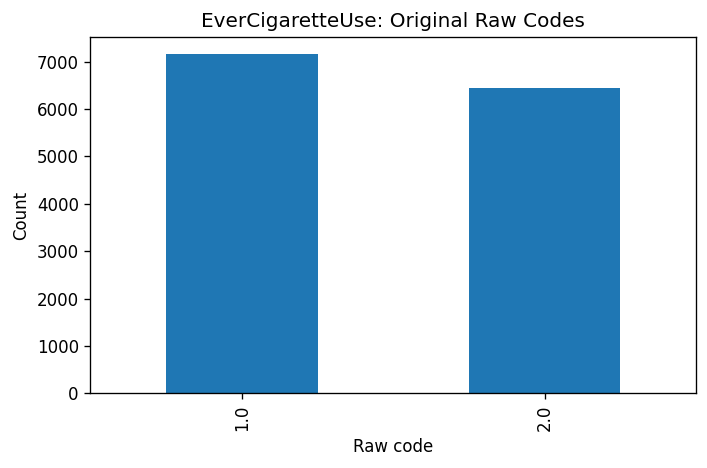

In [110]:

raw_plot_counts = behavior[BEHAVIOR_VAR].dropna().value_counts().sort_index()
plt.figure(figsize=(6, 4))
raw_plot_counts.plot(kind="bar")
plt.title("EverCigaretteUse: Original Raw Codes")
plt.xlabel("Raw code")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_behavior_original_bar_chart.png", bbox_inches="tight")
plt.show()


In [111]:

display(Markdown(
    "**Observation:** Code 1 appears slightly more often than code 2, so the data already suggests "
    "that the sample proportion for the success category may be above 0.50."
))


**Observation:** Code 1 appears slightly more often than code 2, so the data already suggests that the sample proportion for the success category may be above 0.50.

In [112]:

behavior_binary_summary = pd.DataFrame({
    "category": ["Failure (0)", "Success (1)"],
    "count": [
        int((behavior_valid["behavior_binary"] == 0).sum()),
        int((behavior_valid["behavior_binary"] == 1).sum())
    ]
})
behavior_binary_summary["proportion"] = behavior_binary_summary["count"] / behavior_binary_summary["count"].sum()
behavior_binary_summary.to_csv(TAB_DIR / "02_behavior_binary_summary.csv", index=False)
display(behavior_binary_summary)


,category,count,proportion
0,Failure (0),6437,0.473274
1,Success (1),7164,0.526726


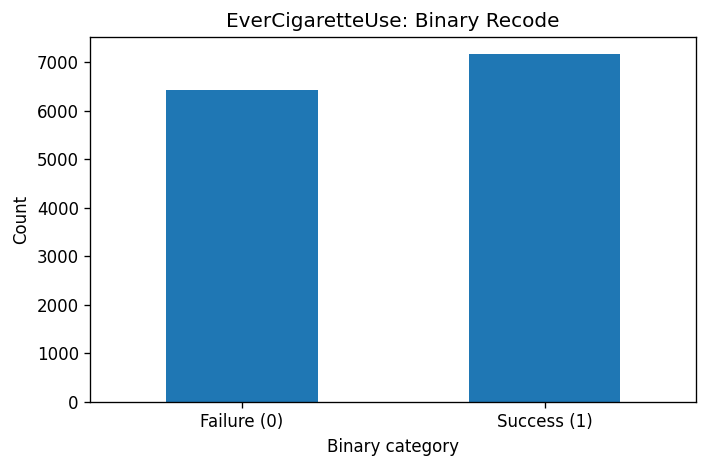

In [113]:

binary_plot_counts = behavior_valid["behavior_binary"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
binary_plot_counts.plot(kind="bar")
plt.title("EverCigaretteUse: Binary Recode")
plt.xlabel("Binary category")
plt.ylabel("Count")
plt.xticks([0, 1], ["Failure (0)", "Success (1)"], rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_behavior_binary_bar_chart.png", bbox_inches="tight")
plt.show()


In [114]:

success_prop = float((behavior_valid["behavior_binary"] == 1).mean())
display(Markdown(
    f"**Observation:** After recoding, the success proportion is **{success_prop:.3f}**. "
    f"The success category is slightly more common than the failure category."
))


**Observation:** After recoding, the success proportion is **0.527**. The success category is slightly more common than the failure category.

,WhatIsYourSex,count,success_proportion
0,1.0,6853,0.506931
1,2.0,6736,0.546912


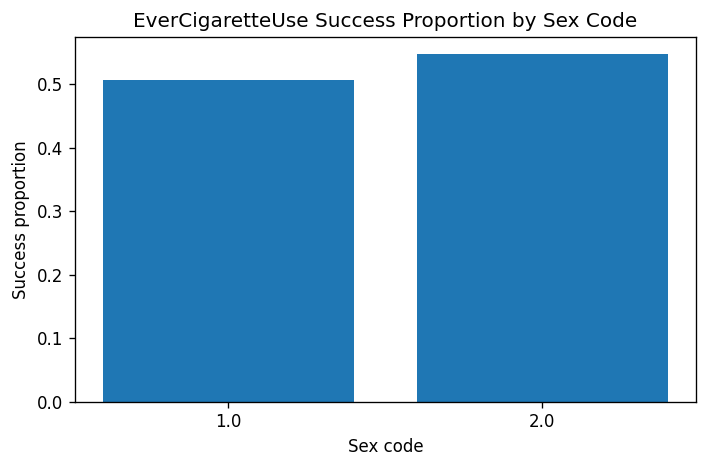

In [115]:

sex_behavior = (
    behavior_valid.groupby("WhatIsYourSex")["behavior_binary"]
    .agg(["count", "mean"])
    .reset_index()
    .rename(columns={"mean": "success_proportion"})
)
sex_behavior.to_csv(TAB_DIR / "02_behavior_by_sex_code.csv", index=False)
display(sex_behavior)

plt.figure(figsize=(6, 4))
plt.bar(sex_behavior["WhatIsYourSex"].astype(str), sex_behavior["success_proportion"])
plt.title("EverCigaretteUse Success Proportion by Sex Code")
plt.xlabel("Sex code")
plt.ylabel("Success proportion")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_behavior_by_sex_code.png", bbox_inches="tight")
plt.show()


In [116]:

row1 = sex_behavior.iloc[0]
row2 = sex_behavior.iloc[1]
display(Markdown(
    f"**Additional EDA note:** The success proportion differs somewhat across the two sex codes "
    f"({row1['success_proportion']:.3f} vs. {row2['success_proportion']:.3f}). "
    "This subgroup view suggests that the overall proportion may combine somewhat different subgroup patterns."
))


**Additional EDA note:** The success proportion differs somewhat across the two sex codes (0.507 vs. 0.547). This subgroup view suggests that the overall proportion may combine somewhat different subgroup patterns.

## Continuous Variable EDA

In [117]:

w = cont_valid[CONT_VAR]
summary_stats = pd.DataFrame({
    "statistic": ["n", "mean", "median", "sd", "min", "Q1", "Q3", "max"],
    "value": [
        int(w.shape[0]),
        float(w.mean()),
        float(w.median()),
        float(w.std(ddof=1)),
        float(w.min()),
        float(w.quantile(0.25)),
        float(w.quantile(0.75)),
        float(w.max())
    ]
})
summary_stats.to_csv(TAB_DIR / "02_continuous_summary_stats.csv", index=False)
display(summary_stats)


,statistic,value
0,n,13062.000000
1,mean,68.550172
2,median,65.320000
3,sd,16.990868
4,min,34.470000
5,Q1,56.700000
6,Q3,77.110000
7,max,180.990000


In [118]:

display(Markdown(
    f"**Observation:** The sample mean is **{w.mean():.2f} kg** and the median is **{w.median():.2f} kg**. "
    "Because the mean is above the median, the distribution appears somewhat right-skewed."
))


**Observation:** The sample mean is **68.55 kg** and the median is **65.32 kg**. Because the mean is above the median, the distribution appears somewhat right-skewed.

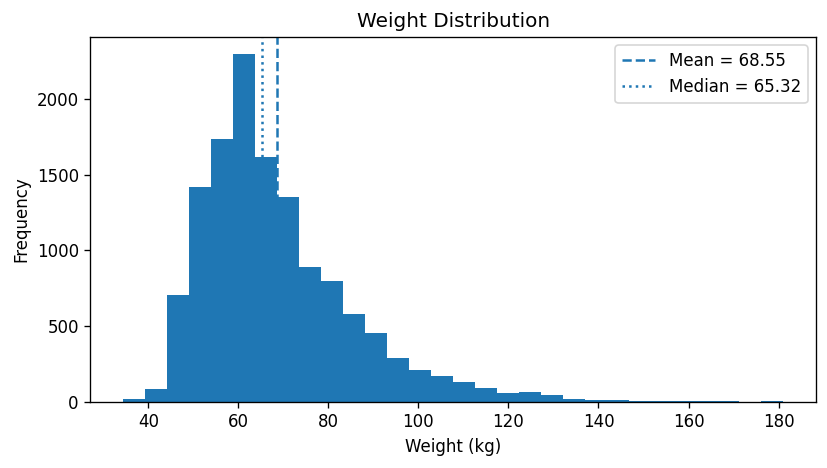

In [119]:

plt.figure(figsize=(7, 4))
plt.hist(w, bins=30)
plt.axvline(w.mean(), linestyle="--", label=f"Mean = {w.mean():.2f}")
plt.axvline(w.median(), linestyle=":", label=f"Median = {w.median():.2f}")
plt.title("Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "02_weight_histogram.png", bbox_inches="tight")
plt.show()


In [120]:

display(Markdown(
    "**Observation:** The histogram shows a single main cluster with a longer right tail. "
    "This supports the idea that unusually high weights pull the mean upward."
))


**Observation:** The histogram shows a single main cluster with a longer right tail. This supports the idea that unusually high weights pull the mean upward.

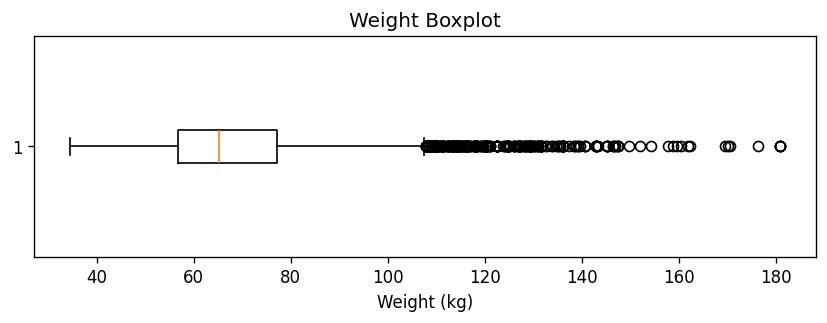

In [121]:

plt.figure(figsize=(7, 2.8))
plt.boxplot(w, vert=False)
plt.title("Weight Boxplot")
plt.xlabel("Weight (kg)")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_weight_boxplot.png", bbox_inches="tight")
plt.show()


In [122]:

q1 = float(w.quantile(0.25))
q3 = float(w.quantile(0.75))
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = int(((w < lower) | (w > upper)).sum())

outlier_table = pd.DataFrame({
    "metric": ["Q1", "Q3", "IQR", "Lower fence", "Upper fence", "Outlier count"],
    "value": [q1, q3, iqr, lower, upper, outliers]
})
outlier_table.to_csv(TAB_DIR / "02_weight_outlier_check.csv", index=False)
display(outlier_table)


,metric,value
0,Q1,56.700
1,Q3,77.110
2,IQR,20.410
3,Lower fence,26.085
4,Upper fence,107.725
5,Outlier count,447.000


In [123]:

display(Markdown(
    f"**Observation:** The IQR rule flags **{outliers}** possible outliers. "
    "So the weight variable is not perfectly symmetric, but the sample size is very large, "
    "which helps make one-sample t procedures reasonably stable."
))


**Observation:** The IQR rule flags **447** possible outliers. So the weight variable is not perfectly symmetric, but the sample size is very large, which helps make one-sample t procedures reasonably stable.

,WhatIsYourSex,count,mean,median,std
0,1.0,6490,62.417296,58.97,14.163778
1,2.0,6572,74.606528,70.76,17.374632


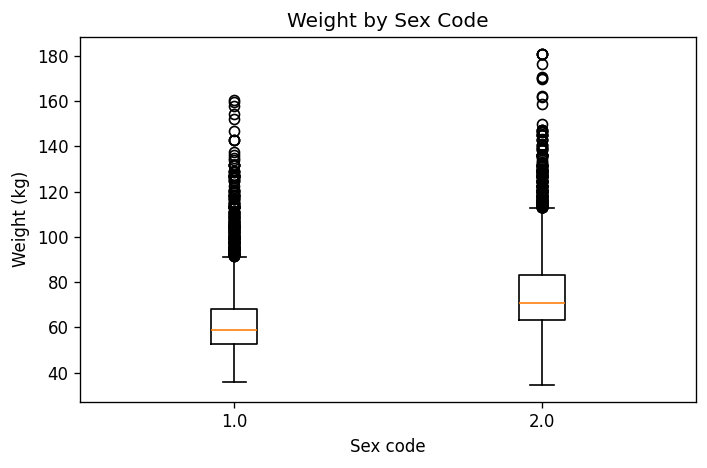

In [124]:

sex_weight = (
    cont_valid.groupby("WhatIsYourSex")[CONT_VAR]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)
sex_weight.to_csv(TAB_DIR / "02_weight_by_sex_code.csv", index=False)
display(sex_weight)

groups = [grp[CONT_VAR].values for _, grp in cont_valid.groupby("WhatIsYourSex")]
labels = [str(code) for code, _ in cont_valid.groupby("WhatIsYourSex")]

plt.figure(figsize=(6, 4))
plt.boxplot(groups, tick_labels=labels)
plt.title("Weight by Sex Code")
plt.xlabel("Sex code")
plt.ylabel("Weight (kg)")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_weight_by_sex_code_boxplot.png", bbox_inches="tight")
plt.show()


In [125]:

display(Markdown(
    f"**Additional EDA note:** The subgroup means differ substantially across the two sex codes "
    f"({sex_weight.loc[0, 'mean']:.2f} kg vs. {sex_weight.loc[1, 'mean']:.2f} kg). "
    "This helps explain some of the spread in the overall distribution."
))


**Additional EDA note:** The subgroup means differ substantially across the two sex codes (62.42 kg vs. 74.61 kg). This helps explain some of the spread in the overall distribution.